# Used Car Price Prediction using Machine Learning
## Problem Statement
Predict the selling price of used cars using machine learning models. Compare various regression models and find out the model which suits the best.

## Objectives
- Perform exploratory data analysis
- Engineer useful features
- Build and compare multiple regression models
- Evaluate model performance using appropriate metrics

## Models Used
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor
- XGBoost Regressor

## Dataset
Source: CarDekho Used Car Dataset     
https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho

In [1]:
#data handling
import pandas as pd

#visualisation
import matplotlib.pyplot as plt
import seaborn as sns

#machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from xgboost import XGBRegressor

from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

In [2]:
#loading the dataset
df = pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [3]:
#dataset overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


The dataset contains information about used cars including name of the car, year of manufacture, kilometres driven, fuel type, seller type (individual, dealer and trustmark dealer), transmission type, owner (first owner, second owner and so on) and selling price.

In [4]:
#Check Missing Values
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

No missing values were detected in the dataset.

In [5]:
#Statistical Summary
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


#### EDA (Exploratory Data analysis)

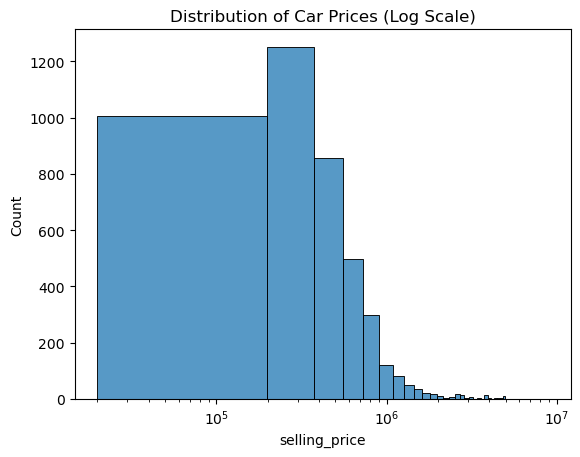

In [6]:
#price distribution
sns.histplot(df["selling_price"], bins=50)
plt.xscale("log")
plt.title("Distribution of Car Prices (Log Scale)")
plt.show()

Text(0.5, 1.0, 'Fuel Type Distribution')

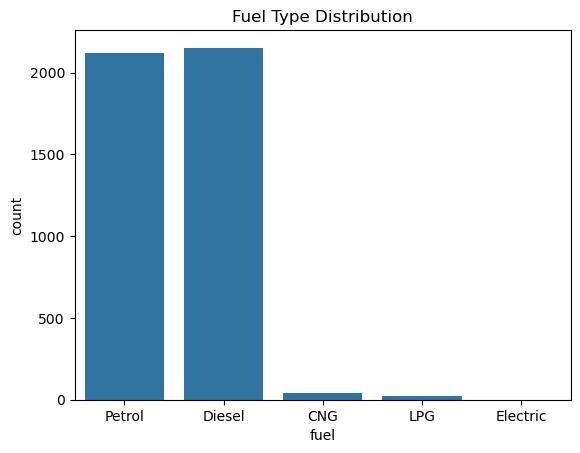

In [7]:
#fuel-type distribution
sns.countplot(x="fuel", data=df)
plt.title("Fuel Type Distribution")

Text(0.5, 1.0, 'Price(log) vs Manufacturing Year')

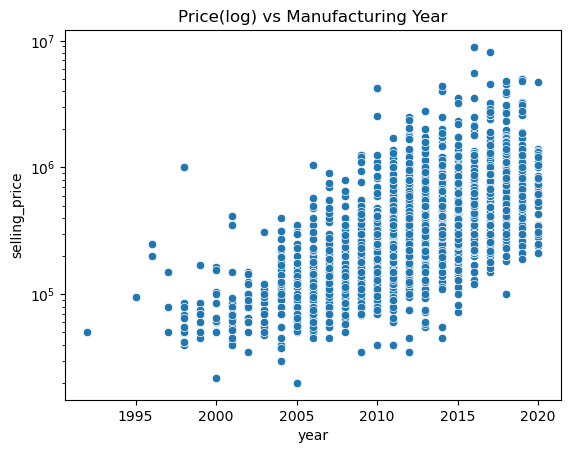

In [8]:
#price vs manufacturing year
sns.scatterplot(x="year", y="selling_price", data=df)
plt.yscale("log")
plt.title("Price(log) vs Manufacturing Year")

#### Feature Engineering

The "name" column contains both brand and model information.  
We extract brand and model to create structured features.

In [9]:
df['Brand'] = df['name'].apply(lambda x : x.split()[0])
df['Model'] = df['name'].apply(lambda x : x.split()[1])

In [10]:
df = df.drop('name', axis = 1)

#### Train-Test split

In [11]:
y = df['selling_price']

In [12]:
X = df.drop('selling_price', axis = 1)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 12)

#### Preprocessing

Defining numerical and categorical columns

In [14]:
X_num = [i for i in X.columns if X[i].dtype != 'O']

In [15]:
X_cat = [i for i in X.columns if X[i].dtype == 'O']

Creating preprocessing pipeline

In [16]:
numeric_transformer = StandardScaler()
ohe_transformer = OneHotEncoder(handle_unknown = 'ignore')

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        ('OneHotEncoder', ohe_transformer, X_cat),
        ('StandardScaler', numeric_transformer, X_num)
    ]
)

In [18]:
preprocessor

ColumnTransformer(transformers=[('OneHotEncoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['fuel', 'seller_type', 'transmission',
                                  'owner', 'Brand', 'Model']),
                                ('StandardScaler', StandardScaler(),
                                 ['year', 'km_driven'])])

#### Defining Models

In [19]:
models = {
    "LinearRegression" : LinearRegression(),
    "DecisionTreeRegressor" : DecisionTreeRegressor(),
    "RandomForestRegressor" : RandomForestRegressor(),
    "GradientBoostingRegressor" : GradientBoostingRegressor(),
    "XGBRegressor" : XGBRegressor()
}


#### Training The Models

In [20]:
results = []
for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    #Train the model
    pipe.fit(X_train, y_train)
    #Predictions
    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)
    #Scores
    results.append({
        "Model": name,
        "R2_train": r2_score(y_train, y_train_pred),
        "RMSE_train": root_mean_squared_error(y_train, y_train_pred),
        "MAE_train": mean_absolute_error(y_train, y_train_pred),
        "R2_test": r2_score(y_test, y_test_pred),
        "RMSE_test": root_mean_squared_error(y_test, y_test_pred),
        "MAE_test": mean_absolute_error(y_test, y_test_pred)
    })

#### Model Comparison Table

In [21]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("RMSE_test")

results_df

,Model,R2_train,RMSE_train,MAE_train,R2_test,RMSE_test,MAE_test
4,XGBRegressor,0.981532,78940.618536,54816.258527,0.887644,190639.647956,86479.172665
3,GradientBoostingRegressor,0.913258,171084.225013,120319.275813,0.813193,245816.609654,137742.987187
2,RandomForestRegressor,0.971876,97416.964142,35177.360433,0.808788,248697.868593,87850.452712
0,LinearRegression,0.910685,173602.773877,104534.506193,0.805494,250830.709380,122181.833066
1,DecisionTreeRegressor,0.999243,15985.062995,3005.856903,0.767252,274382.963164,96974.010177


#### Model Evaluation & Comparison

##### Model Performance Metrics

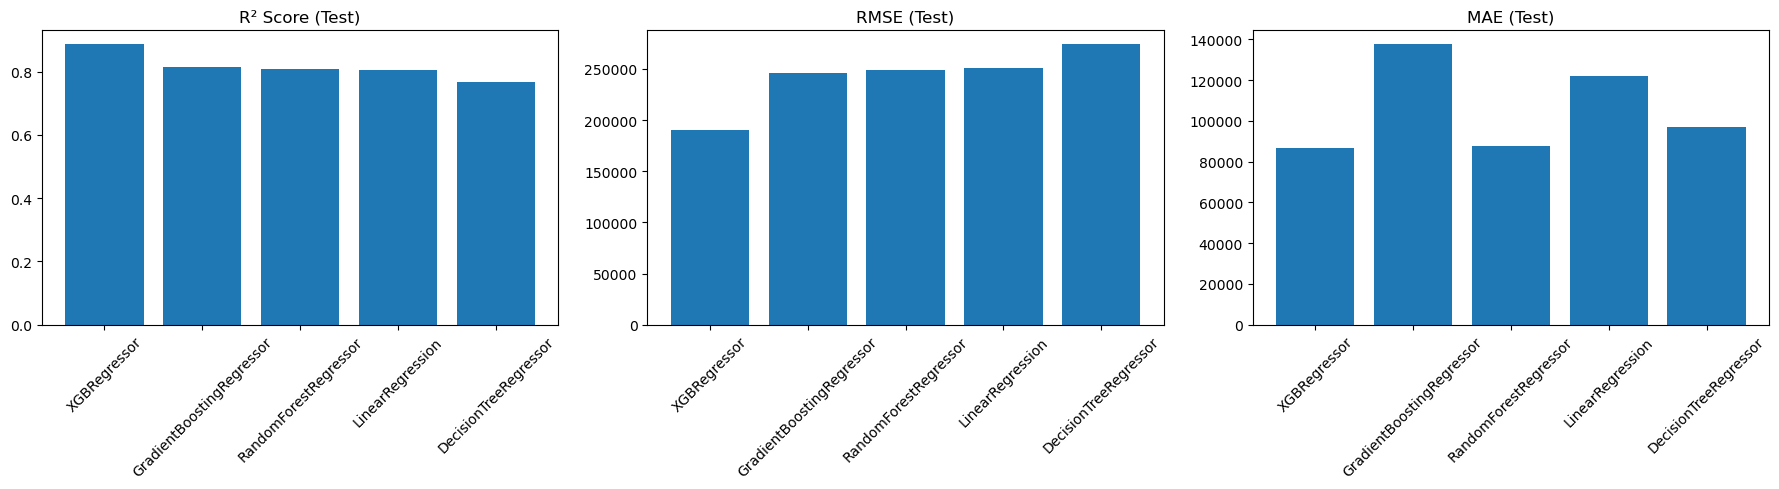

In [22]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

axes[0].bar(results_df["Model"], results_df["R2_test"])
axes[0].set_title("R² Score (Test)")
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(results_df["Model"], results_df["RMSE_test"])
axes[1].set_title("RMSE (Test)")
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(results_df["Model"], results_df["MAE_test"])
axes[2].set_title("MAE (Test)")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

##### Train vs Test Comparison Plots

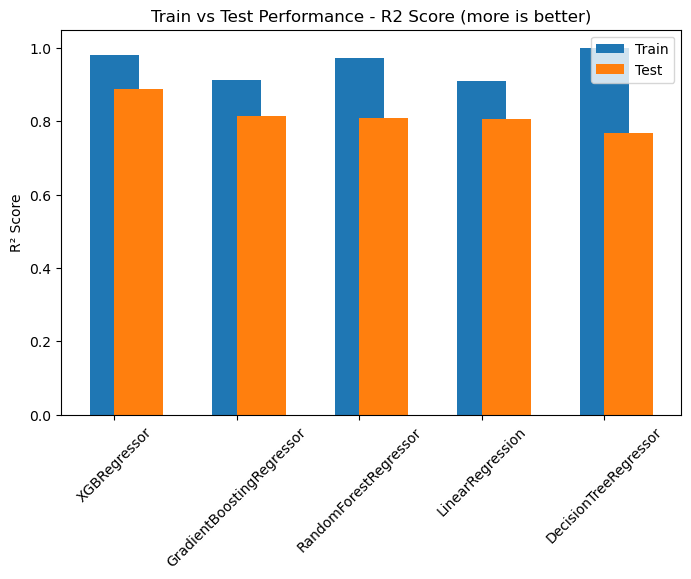

In [23]:
plt.figure(figsize=(8,5))

x = range(len(results_df))

plt.bar(x, results_df["R2_train"], width=0.4, label="Train", align='center')
plt.bar(x, results_df["R2_test"], width=0.4, label="Test", align='edge')

plt.xticks(x, results_df["Model"], rotation=45)
plt.ylabel("R² Score")
plt.title("Train vs Test Performance - R2 Score (more is better)")

plt.legend()
plt.show()

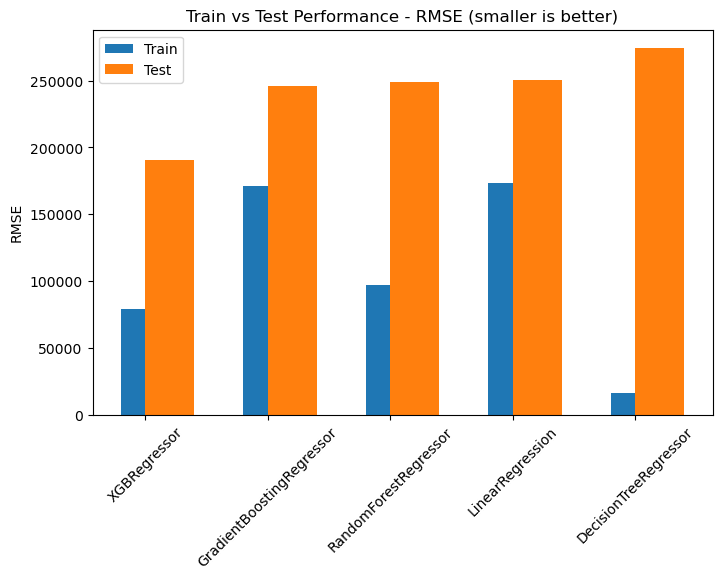

In [24]:
plt.figure(figsize=(8,5))

x = range(len(results_df))

plt.bar(x, results_df["RMSE_train"], width=0.4, label="Train", align='center')
plt.bar(x, results_df["RMSE_test"], width=0.4, label="Test", align='edge')

plt.xticks(x, results_df["Model"], rotation=45)
plt.ylabel("RMSE")
plt.title("Train vs Test Performance - RMSE (smaller is better)")

plt.legend()
plt.show()

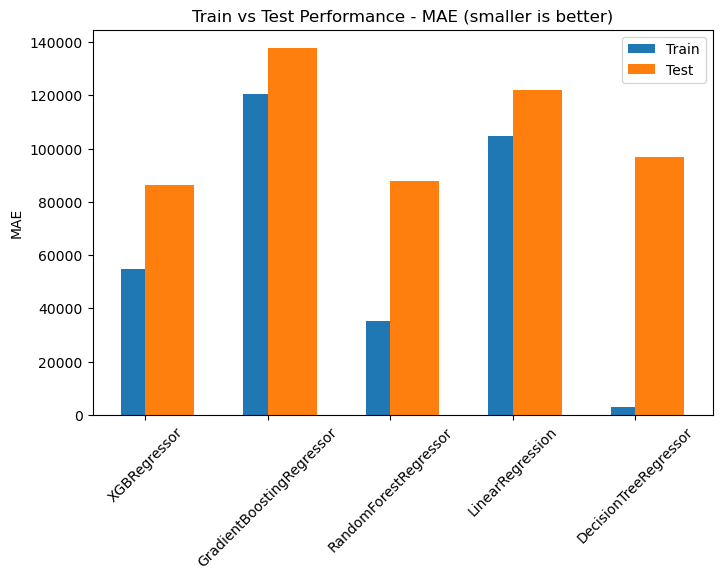

In [25]:
plt.figure(figsize=(8,5))

x = range(len(results_df))

plt.bar(x, results_df["MAE_train"], width=0.4, label="Train", align='center')
plt.bar(x, results_df["MAE_test"], width=0.4, label="Test", align='edge')

plt.xticks(x, results_df["Model"], rotation=45)
plt.ylabel("MAE")
plt.title("Train vs Test Performance - MAE (smaller is better)")

plt.legend()
plt.show()

##### Best Model Selection

From the evaluation metrics and comparison plots, the **XGBoost Regressor**
achieved the best performance with the highest R² score and lowest RMSE and MAE.     
Therefore, further analysis will be performed using the XGBoost model.

##### Actual vs Predicted Plot

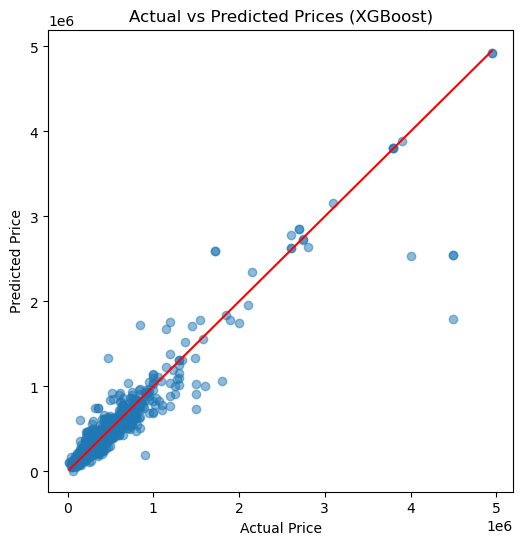

In [26]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_test_pred, alpha=0.5)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices (XGBoost)")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

(Here, red line indicates perfect predictions)

##### Residual Analysis

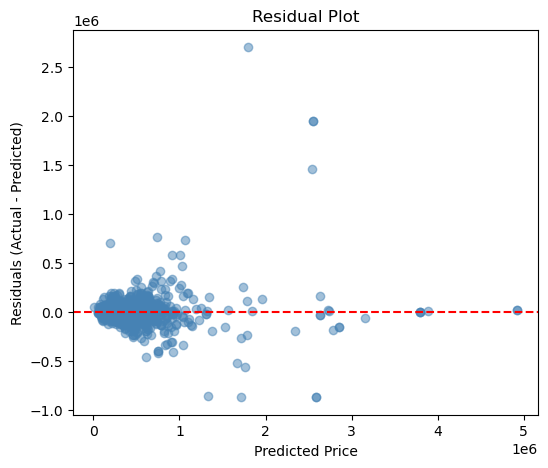

In [27]:
residuals = y_test - y_test_pred

plt.figure(figsize=(6,5))

plt.scatter(y_test_pred, residuals, alpha=0.5, color = 'steelblue')

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Price")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")

plt.show()

## Conclusion

In this project, multiple regression models were trained to predict the selling price of used cars. 
The models evaluated include Linear Regression, Decision Tree Regressor, Random Forest Regressor, 
Gradient Boosting Regressor, and XGBoost Regressor.

Based on the evaluation metrics (R² score, RMSE, and MAE), the **XGBoost Regressor achieved the best performance**
on the test dataset.

The residual analysis shows that prediction errors are generally centered around zero, indicating that the model 
does not exhibit strong systematic bias.

Overall, the results demonstrate that ensemble tree-based models such as XGBoost perform well for structured 
tabular data problems like used car price prediction.

Future improvements could include:
- hyperparameter tuning
- additional feature engineering
- handling high-cardinality categorical variables more effectively